In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_excel('../../dataset/all data.xlsx',sheet_name='new')

In [6]:
group_reference = data['Reference'].copy()

In [7]:
data['logIpc'] = np.log10(data['Ipc'])
data['logSRC'] = np.log10(data['Soil residual concentration'])
data['logED'] = np.log10(data['ED'])

In [8]:
data.drop(columns=['Reference', 'Sample','Soil source','ES','PFAS','PFAS class','Species','Plant class','group','Ipc','Original tissue',
                   'ED','Soil residual concentration'], inplace=True)
X = data.drop(columns=['lnBCF'])

In [9]:
cat_cols = [
    'Tissue',
    'Family','Genus','Order','monocot','woody','herb','crop','vegetable','legume','grass','perennial','edible'
]
cat_cols = [c for c in cat_cols if c in X.columns] 
num_cols = [c for c in X.columns if c not in cat_cols]

In [12]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

X_processed = preprocessor.fit_transform(X)

# sparse -> dense
if hasattr(X_processed, "toarray"):
    X_dense = X_processed.toarray()
else:
    X_dense = X_processed

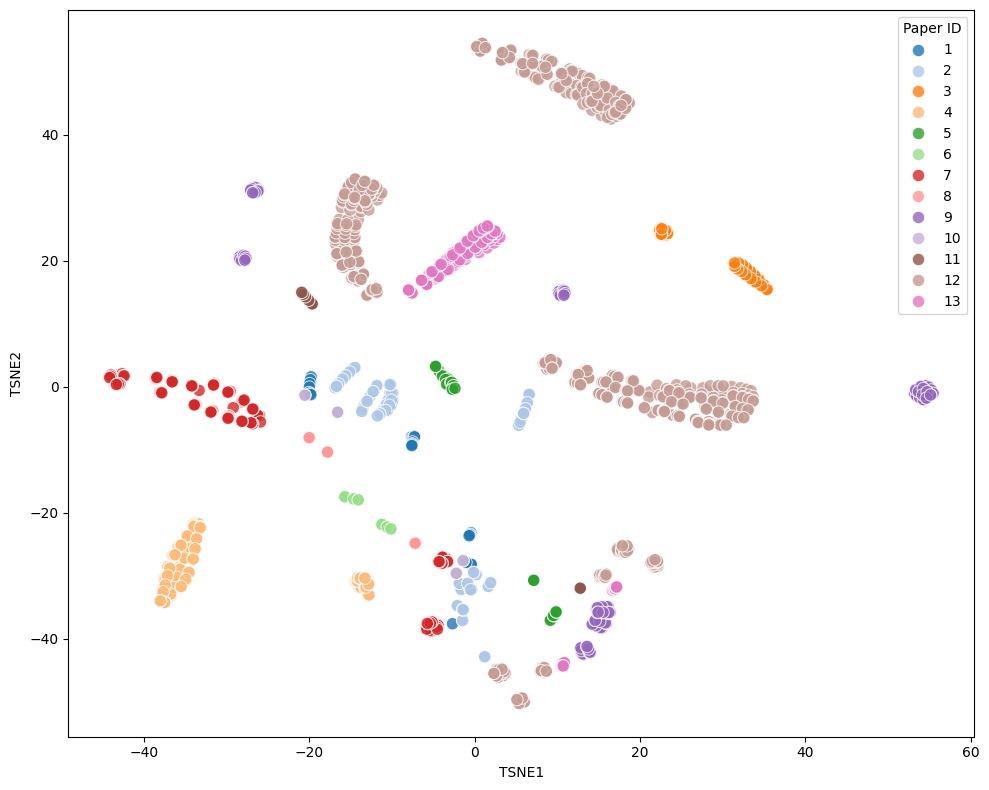

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_dense)

tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:,0],
    'TSNE2': X_tsne[:,1],
    'Paper ID': group_reference.astype(str)
})

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='Paper ID',
    palette='tab20',
    s=80,
    alpha=0.8
)

#plt.title('t-SNE Projection of Different Studies')

plt.tight_layout()
plt.savefig('../../Fig/TSNE_reference.png', dpi=600)
plt.savefig('../../Fig/TSNE_reference.pdf', dpi=600)

plt.show()